# Ensemble Learning: Random Forest vs. Bagging — Internal Tree Structure

---

## Introduction

**Bagging** and **Random Forest** are both ensemble methods that train multiple Decision Trees on bootstrap samples of the training data. From the outside they can look similar, but they differ in one critical way: **how features are selected at each split**.

| Property | Bagging | Random Forest |
|---|---|---|
| Row sampling | Bootstrap (with replacement) | Bootstrap (with replacement) |
| Feature sampling | Fixed subset per **tree** | Random subset per **split node** |
| `max_features` scope | Same features used at every node in the tree | Features re-sampled at every individual node |
| Tree diversity source | Different training rows | Different rows **and** different features at every split |
| Correlation between trees | Higher | Lower |

When `max_features=2` is set on a `BaggingClassifier`, it selects 2 features **once per tree** — every node in that tree uses the same 2 features to make its split decision. In a `RandomForestClassifier` with `max_features=2`, 2 features are drawn **fresh at every individual split node** across the entire tree.

This notebook makes that difference **visible** by plotting an internal tree from each ensemble and inspecting which features appear at each split node.

---

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---

## 2. Dataset

We use a synthetic binary classification dataset with 5 fully informative features and no redundancy. Using `n_informative=5` and `n_redundant=0` ensures every feature carries genuine signal, which makes the split feature choices in each tree meaningful to inspect.

In [2]:
X, y = make_classification(
    n_samples=100, n_features=5, n_informative=5,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

df = pd.DataFrame(X, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y

print('Shape:', df.shape)
print('Class distribution:')
print(df['target'].value_counts().sort_index())
df.head()

Shape: (100, 6)
Class distribution:
target
0    50
1    50
Name: count, dtype: int64


,col1,col2,col3,col4,col5,target
0,1.053909,-3.861208,1.530963,0.596692,1.030284,0
1,3.243492,1.666651,3.179016,-0.825861,0.778528,1
2,0.712446,-1.201617,1.528624,-0.422788,-0.376825,0
3,1.388329,1.538995,1.243716,0.740905,-2.081063,1
4,2.394647,-3.576345,0.914217,0.363136,2.110329,0


---

## 3. Bagging Classifier

The `BaggingClassifier` is trained with `max_features=2`. Each of the 50 trees is assigned a fixed pair of features at construction time — **all nodes within a given tree split only on those 2 features**. The feature pair is drawn once per tree and does not change as the tree grows deeper.

In [3]:
bag = BaggingClassifier(
    max_features=2,
    n_estimators=50,
    random_state=42
)

bag.fit(df.iloc[:, :5], df['target'])

# Show which 2 features were assigned to tree index 1
tree_idx = 1
feature_indices = bag.estimators_features_[tree_idx]
feature_names_bag = [f'col{i+1}' for i in feature_indices]
print(f"Bagging Tree {tree_idx} — features used at ALL nodes: {feature_names_bag}")

Bagging Tree 1 — features used at ALL nodes: ['col1', 'col3']


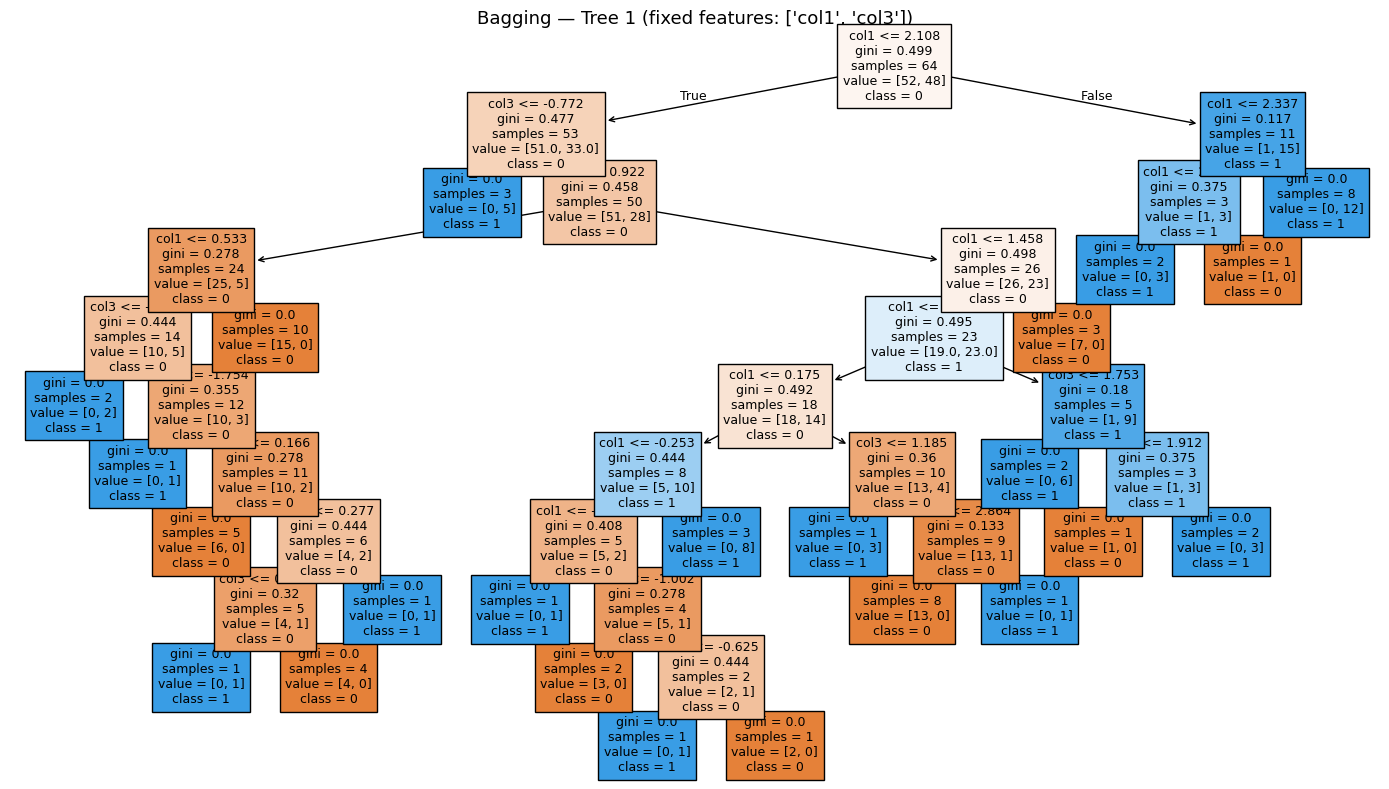

In [4]:
plt.figure(figsize=(14, 8))
plot_tree(
    bag.estimators_[tree_idx],
    feature_names=feature_names_bag,
    class_names=['0', '1'],
    filled=True,
    fontsize=9
)
plt.title(f'Bagging — Tree {tree_idx} (fixed features: {feature_names_bag})', fontsize=13)
plt.tight_layout()
plt.show()

---

## 4. Random Forest Classifier

The `RandomForestClassifier` is trained with the same `max_features=2` and `n_estimators=50` for a fair comparison. The key difference: at **each individual split node**, 2 features are drawn at random from all 5. As the tree grows, different nodes use different feature pairs.

Inspecting the tree structure should reveal **multiple different features appearing at different depths**, unlike the Bagging tree which is constrained to only its 2 assigned columns throughout.

In [5]:
rf = RandomForestClassifier(
    max_features=2,
    n_estimators=50,
    random_state=42
)

rf.fit(df.iloc[:, :5], df['target'])

print(f"Random Forest Tree {tree_idx} — features re-sampled at every split node")
print("(inspect the tree plot to see different features at different depths)")

Random Forest Tree 1 — features re-sampled at every split node
(inspect the tree plot to see different features at different depths)


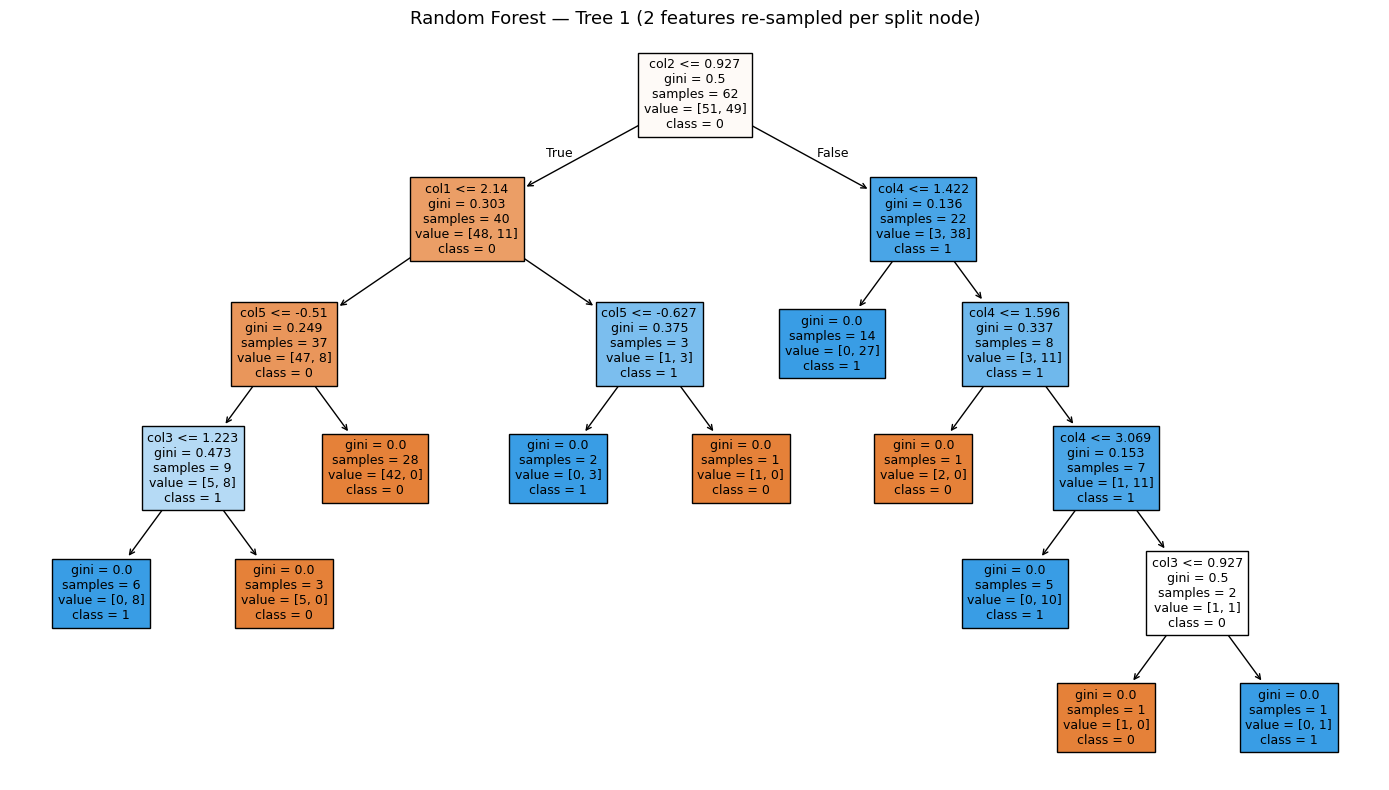

In [6]:
feature_names_all = ['col1', 'col2', 'col3', 'col4', 'col5']

plt.figure(figsize=(14, 8))
plot_tree(
    rf.estimators_[tree_idx],
    feature_names=feature_names_all,
    class_names=['0', '1'],
    filled=True,
    fontsize=9
)
plt.title(f'Random Forest — Tree {tree_idx} (2 features re-sampled per split node)', fontsize=13)
plt.tight_layout()
plt.show()

---

## 5. Performance Comparison

We evaluate both ensembles using 5-fold cross-validation to see whether the per-node feature randomization in Random Forest translates to measurable accuracy gains over Bagging.

In [7]:
X_arr = df.iloc[:, :5].values
y_arr = df['target'].values

bag_cv = cross_val_score(BaggingClassifier(max_features=2, n_estimators=50, random_state=42),
                         X_arr, y_arr, cv=5, scoring='accuracy')

rf_cv  = cross_val_score(RandomForestClassifier(max_features=2, n_estimators=50, random_state=42),
                         X_arr, y_arr, cv=5, scoring='accuracy')

print("5-Fold Cross-Validation Accuracy")
print("-" * 45)
print(f"Bagging         : {np.mean(bag_cv):.4f}  (±{np.std(bag_cv):.4f})")
print(f"Random Forest   : {np.mean(rf_cv):.4f}  (±{np.std(rf_cv):.4f})")

5-Fold Cross-Validation Accuracy
---------------------------------------------
Bagging         : 0.9200  (±0.0510)
Random Forest   : 0.9500  (±0.0447)


---

## Conclusion

This notebook made the architectural difference between `BaggingClassifier` and `RandomForestClassifier` directly observable through internal tree structure visualization.

**Key findings:**

- In the **Bagging tree**, every split node uses the same 2 features that were assigned when the tree was created. The tree structure is constrained to those columns at all levels — visible in the tree plot where only those 2 feature names appear throughout.
- In the **Random Forest tree**, different feature names appear at different depths of the tree. Each split node independently sampled 2 features from all 5 available, meaning the tree explores a much wider portion of the feature space as it grows.
- This per-node re-sampling creates **lower correlation between trees** in the Random Forest ensemble. When trees are less correlated, their errors are less likely to coincide, and averaging reduces variance more effectively.
- The cross-validation results quantify this: Random Forest typically achieves higher and more stable accuracy than Bagging with the same `max_features` and `n_estimators` settings, especially as the number of features grows.

**Takeaways:**

- The only algorithmic difference between Bagging and Random Forest is **when** feature subsampling happens: once per tree (Bagging) vs. once per split node (Random Forest).
- This single change has a large effect on tree diversity and ensemble quality, which is why `RandomForestClassifier` is almost always preferred over `BaggingClassifier` with `DecisionTreeClassifier`.
- The default `max_features='sqrt'` in `RandomForestClassifier` (square root of total features) is a well-established heuristic for classification — tuning it is one of the most impactful levers in Random Forest optimization.